# Notebook 03: Attention Mechanism

## Overview

- **Duration**: ~4 hours
- **Prerequisites**: Notebooks 01-02, linear algebra basics
- **Learning Objectives**:
  1. Understand Query, Key, Value projections
  2. Implement scaled dot-product attention from scratch
  3. Implement causal masking for autoregressive models
  4. Implement multi-head attention
  5. Visualize attention patterns

## Introduction

Attention is the core innovation of transformers. It allows the model to "attend" to different parts of the input sequence when producing each output.

### The Key Insight

For each position, attention computes a weighted average of all positions, where the weights depend on the content.

### The Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
- **Q (Query)**: What am I looking for?
- **K (Key)**: What do I contain?
- **V (Value)**: What information do I provide?

### Reference Materials

- [The Annotated Transformer](http://nlp.seas.harvard.edu/2018/04/03/attention.html)
- [UvA Deep Learning Tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial6/Transformers_and_MHAttention.html)

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# For reproducibility
torch.manual_seed(42)

Using device: cpu


## 2. Understanding Attention Intuitively

Think of attention as a soft dictionary lookup:
- You have a **query** (what you're looking for)
- The dictionary has **keys** (what each entry is about)
- The dictionary has **values** (the actual content)
- Instead of exact matching, we compute similarity scores

In [3]:
# Simple example: dictionary lookup
# Imagine we have 4 "slots" in memory, each with a key and value

# Keys describe what's stored (e.g., "color", "size", "shape", "texture")
keys = torch.tensor([
    [1.0, 0.0],  # Slot 0: about "visual appearance"
    [0.0, 1.0],  # Slot 1: about "physical properties"
    [0.5, 0.5],  # Slot 2: about both
    [0.2, 0.8],  # Slot 3: mostly "physical"
])

# Values are the actual information
values = torch.tensor([
    [1.0, 0.0, 0.0],  # Red
    [0.0, 1.0, 0.0],  # Heavy
    [0.0, 0.0, 1.0],  # Round
    [0.5, 0.5, 0.0],  # Orange and medium weight
])

# Query: "I want to know about visual appearance"
query = torch.tensor([[1.0, 0.0]])

# Compute attention scores
scores = query @ keys.T  # shape: (1, 4)
weights = F.softmax(scores, dim=-1)
output = weights @ values

print("Query (looking for visual info):")
print(f"  Attention scores (before softmax): {scores[0].tolist()}")
print(f"  Attention weights: {weights[0].tolist()}")
print(f"  Output: {output[0].tolist()}")
print("  -> Mostly gets info from slot 0 (visual)")

Query (looking for visual info):
  Attention scores (before softmax): [1.0, 0.0, 0.5, 0.20000000298023224]
  Attention weights: [0.41258567571640015, 0.15178179740905762, 0.2502458691596985, 0.18538668751716614]
  Output: [0.505279004573822, 0.24447514116764069, 0.2502458691596985]
  -> Mostly gets info from slot 0 (visual)


## 3. Exercises

### Exercise 3.1: Scaled Dot-Product Attention (40 min)

Implement the core attention mechanism:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Why scale by √d_k?**

When d_k is large, the dot products can become very large, pushing the softmax into regions with extremely small gradients. Scaling keeps the gradients healthy.

In [8]:
####solution 3.1
def scaled_dot_product_attention(
    query: torch.Tensor,  # (batch, seq_len, d_k)
    key: torch.Tensor,    # (batch, seq_len, d_k)
    value: torch.Tensor,  # (batch, seq_len, d_v)
    mask: torch.Tensor = None,  # (batch, seq_len, seq_len) or (1, seq_len, seq_len)
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Compute scaled dot-product attention.
    
    Args:
        query: Query tensor
        key: Key tensor
        value: Value tensor
        mask: Optional mask (0 = attend, -inf = don't attend)
        
    Returns:
        output: Attention output of shape (batch, seq_len, d_v)
        attention_weights: Attention weights of shape (batch, seq_len, seq_len)
    """
    # TODO: Implement scaled dot-product attention
    # Step 1: Compute attention scores: QK^T / sqrt(d_k)
    #         scores shape: (batch, seq_len, seq_len)
    scores = query @ key.transpose(-2, -1) / math.sqrt(query.size(-1))
    # Step 2: Apply mask (if provided)
    #         Where mask == 0, set scores to -inf
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    # Step 3: Apply softmax to get attention weights
    attention_weights = F.softmax(scores, dim=-1)
    # Step 4: Compute weighted sum of values
    #         output = attention_weights @ value
    output = attention_weights @ value

    return output, attention_weights

In [9]:
####test cell
# Test your implementation
batch_size = 2
seq_len = 4
d_k = 8

q = torch.randn(batch_size, seq_len, d_k)
k = torch.randn(batch_size, seq_len, d_k)
v = torch.randn(batch_size, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(q, k, v)

print(f"Query shape: {q.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

# Validations
assert output.shape == (batch_size, seq_len, d_k)
assert attn_weights.shape == (batch_size, seq_len, seq_len)

# Attention weights should sum to 1 along last dimension
assert torch.allclose(attn_weights.sum(dim=-1), torch.ones(batch_size, seq_len), atol=1e-5)

print("\n✓ Exercise 3.1 passed!")

Query shape: torch.Size([2, 4, 8])
Output shape: torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 4, 4])

✓ Exercise 3.1 passed!


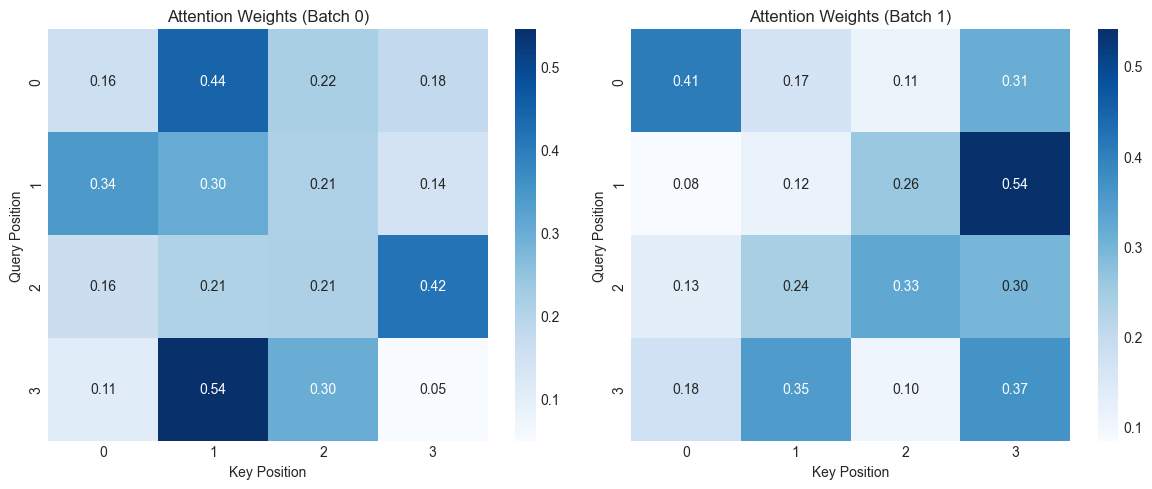

In [10]:
####plot cell
# Visualize attention weights
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, ax in enumerate(axes):
    sns.heatmap(attn_weights[i].detach().numpy(), ax=ax, cmap='Blues', annot=True, fmt='.2f')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')
    ax.set_title(f'Attention Weights (Batch {i})')

plt.tight_layout()
plt.show()

### Exercise 3.2: Causal Masking (30 min)

For autoregressive models (like GPT), each position should only attend to previous positions. We implement this with a **causal mask**.

The mask is a lower triangular matrix:
```
[[1, 0, 0, 0],
 [1, 1, 0, 0],
 [1, 1, 1, 0],
 [1, 1, 1, 1]]
```

Where 1 = attend, 0 = don't attend (will be -inf in scores).

In [11]:
####solution 3.2
def create_causal_mask(seq_len: int) -> torch.Tensor:
    """
    Create a causal mask for autoregressive attention.
    
    Args:
        seq_len: Sequence length
        
    Returns:
        mask: Lower triangular mask of shape (1, seq_len, seq_len)
              1 = attend, 0 = don't attend
    """
    # TODO: Create a lower triangular mask
    # Hint: Use torch.tril() or torch.ones() with appropriate operations
    return torch.tril(torch.ones(1, seq_len, seq_len))

In [12]:
####test cell
# Test causal mask
seq_len = 5
mask = create_causal_mask(seq_len)

print(f"Causal mask shape: {mask.shape}")
print(f"Mask:\n{mask[0]}")

# Validation
expected = torch.tril(torch.ones(seq_len, seq_len))
assert torch.allclose(mask[0], expected), "Mask should be lower triangular"
print("\n✓ Causal mask correct!")

Causal mask shape: torch.Size([1, 5, 5])
Mask:
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

✓ Causal mask correct!


In [13]:
####test cell
# Test attention with causal mask
q = torch.randn(1, 5, 8)
k = torch.randn(1, 5, 8)
v = torch.randn(1, 5, 8)

mask = create_causal_mask(5)
output, attn_weights = scaled_dot_product_attention(q, k, v, mask)

print("Attention weights with causal mask:")
print(attn_weights[0].detach().numpy().round(3))

# Check that future positions have zero attention
upper_tri = torch.triu(attn_weights[0], diagonal=1)
assert torch.allclose(upper_tri, torch.zeros_like(upper_tri), atol=1e-6), \
    "Upper triangular should be all zeros (no attending to future)"
print("\n✓ Exercise 3.2 passed!")

Attention weights with causal mask:
[[1.    0.    0.    0.    0.   ]
 [0.521 0.479 0.    0.    0.   ]
 [0.559 0.276 0.165 0.    0.   ]
 [0.175 0.198 0.592 0.035 0.   ]
 [0.076 0.157 0.068 0.15  0.549]]

✓ Exercise 3.2 passed!


### Exercise 3.3: Single-Head Attention Module (30 min)

Create a proper PyTorch module for single-head attention with learnable projections.

In [16]:
####solution 3.3
class SingleHeadAttention(nn.Module):
    """
    Single-head self-attention with causal masking.
    
    Args:
        d_model: Model dimension
        d_k: Key/Query dimension (often d_model)
        d_v: Value dimension (often d_model)
        max_len: Maximum sequence length (for causal mask)
        dropout: Dropout probability
    """
    
    def __init__(
        self,
        d_model: int,
        d_k: int = None,
        d_v: int = None,
        max_len: int = 512,
        dropout: float = 0.1,
    ):
        super().__init__()
        d_k = d_k or d_model
        d_v = d_v or d_model
        
        # TODO: Create linear projections for Q, K, V
        # self.W_q: Linear layer mapping d_model -> d_k
        self.W_q = nn.Linear(d_model, d_k)
        # self.W_k: Linear layer mapping d_model -> d_k
        self.W_k = nn.Linear(d_model, d_k)
        # self.W_v: Linear layer mapping d_model -> d_v
        self.W_v = nn.Linear(d_model, d_v)
        # self.W_o: Output projection mapping d_v -> d_model
        self.W_o = nn.Linear(d_v, d_model)

        # TODO: Create dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # TODO: Register causal mask as buffer
        # Use self.register_buffer('mask', create_causal_mask(max_len))
        self.register_buffer('mask', create_causal_mask(max_len))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input of shape (batch, seq_len, d_model)
            
        Returns:
            Output of shape (batch, seq_len, d_model)
        """
        # TODO:
        # 1. Project to Q, K, V
        # 2. Apply scaled dot-product attention with causal mask
        # 3. Apply output projection
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)

        # Slice mask to match current sequence length
        mask = self.mask[:, :seq_len, :seq_len]

        output, weights = scaled_dot_product_attention(q, k, v, mask)

        output = self.W_o(output)
        output = self.dropout(output)

        return output

In [17]:
####test cell
# Test single-head attention
d_model = 64
batch_size = 2
seq_len = 10

attention = SingleHeadAttention(d_model, max_len=512, dropout=0.0)
x = torch.randn(batch_size, seq_len, d_model)
output = attention(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

assert output.shape == x.shape
print("\n✓ Exercise 3.3 passed!")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])

✓ Exercise 3.3 passed!


### Exercise 3.4: Multi-Head Attention (45 min)

Multi-head attention runs multiple attention operations in parallel, each with different learned projections. This allows the model to attend to information from different representation subspaces.

**Implementation trick**: Instead of creating separate Q, K, V projections for each head, we create one large projection and reshape.

In [23]:
####solution 3.4
class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention with causal masking.
    
    Args:
        d_model: Model dimension
        n_heads: Number of attention heads
        max_len: Maximum sequence length
        dropout: Dropout probability
    """
    
    def __init__(
        self,
        d_model: int,
        n_heads: int,
        max_len: int = 512,
        dropout: float = 0.1,
    ):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        # TODO: Create combined Q, K, V projection (more efficient)
        # self.qkv_proj: Linear layer mapping d_model -> 3 * d_model
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        # TODO: Create output projection
        # self.out_proj: Linear layer mapping d_model -> d_model
        self.out_proj = nn.Linear(d_model, d_model)
        # TODO: Create dropout layers
        self.dropout = nn.Dropout(dropout)
        # TODO: Register causal mask as buffer
        self.register_buffer('mask', create_causal_mask(max_len))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input of shape (batch, seq_len, d_model)
            
        Returns:
            Output of shape (batch, seq_len, d_model)
        """
        batch_size, seq_len, _ = x.shape
        
        # TODO:
        # 1. Project to Q, K, V using combined projection
        #    qkv = self.qkv_proj(x)  # (batch, seq_len, 3 * d_model)
        #    Split into q, k, v each of shape (batch, seq_len, d_model)
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)
        # 2. Reshape for multi-head attention
        #    (batch, seq_len, d_model) -> (batch, n_heads, seq_len, head_dim)
        #    Hint: view(batch, seq_len, n_heads, head_dim).transpose(1, 2)
        q = q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        # 3. Compute attention for all heads in parallel
        #    - Scale queries by 1/sqrt(head_dim)
        #    - Compute scores: q @ k.transpose(-2, -1)
        #    - Apply causal mask
        #    - Softmax and dropout
        #    - Multiply by values
        attention, _ = scaled_dot_product_attention(q, k, v, self.mask[:, :seq_len, :seq_len])
        
        # 4. Reshape back: (batch, n_heads, seq_len, head_dim) -> (batch, seq_len, d_model)
        #    Hint: transpose(1, 2).contiguous().view(batch, seq_len, d_model)
        output = attention.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # 5. Apply output projection
        output = self.out_proj(output)
        output = self.dropout(output)
        
        return output

In [24]:
####test cell
# Test multi-head attention
d_model = 64
n_heads = 8
batch_size = 2
seq_len = 10

mha = MultiHeadAttention(d_model, n_heads, max_len=512, dropout=0.0)
x = torch.randn(batch_size, seq_len, d_model)
output = mha(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Number of heads: {n_heads}")
print(f"Head dimension: {d_model // n_heads}")

assert output.shape == x.shape
print("\n✓ Exercise 3.4 passed!")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Number of heads: 8
Head dimension: 8

✓ Exercise 3.4 passed!


## 4. Compare with PyTorch Implementation

In [25]:
# Compare with PyTorch's built-in MultiheadAttention
pytorch_mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=n_heads,
    dropout=0.0,
    batch_first=True,
)

# Create causal mask for PyTorch (uses additive mask with -inf)
pytorch_mask = torch.triu(torch.ones(seq_len, seq_len) * float('-inf'), diagonal=1)

x = torch.randn(batch_size, seq_len, d_model)

# Our implementation
our_output = mha(x)

# PyTorch implementation
pytorch_output, _ = pytorch_mha(x, x, x, attn_mask=pytorch_mask)

print(f"Our output shape: {our_output.shape}")
print(f"PyTorch output shape: {pytorch_output.shape}")

# Note: Outputs won't be identical due to different weight initialization
# but shapes and properties should match

Our output shape: torch.Size([2, 10, 64])
PyTorch output shape: torch.Size([2, 10, 64])


## 5. Visualize Attention Patterns

In [28]:
# Add a method to extract attention weights for visualization
# This is a modified version that returns attention weights

def get_attention_weights(mha: MultiHeadAttention, x: torch.Tensor) -> torch.Tensor:
    """
    Get attention weights from multi-head attention.
    Returns shape: (batch, n_heads, seq_len, seq_len)
    """
    batch_size, seq_len, _ = x.shape
    
    # Project to Q, K, V
    qkv = mha.qkv_proj(x)
    q, k, v = qkv.chunk(3, dim=-1)
    
    # Reshape for multi-head
    q = q.view(batch_size, seq_len, mha.n_heads, mha.head_dim).transpose(1, 2)
    k = k.view(batch_size, seq_len, mha.n_heads, mha.head_dim).transpose(1, 2)
    
    # Compute attention scores
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(mha.head_dim)
    
    # Apply causal mask
    mask = mha.mask[:, :seq_len, :seq_len]
    #mask = mha.mask[:, :, :seq_len, :seq_len]
    scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Softmax
    attn_weights = F.softmax(scores, dim=-1)
    
    return attn_weights

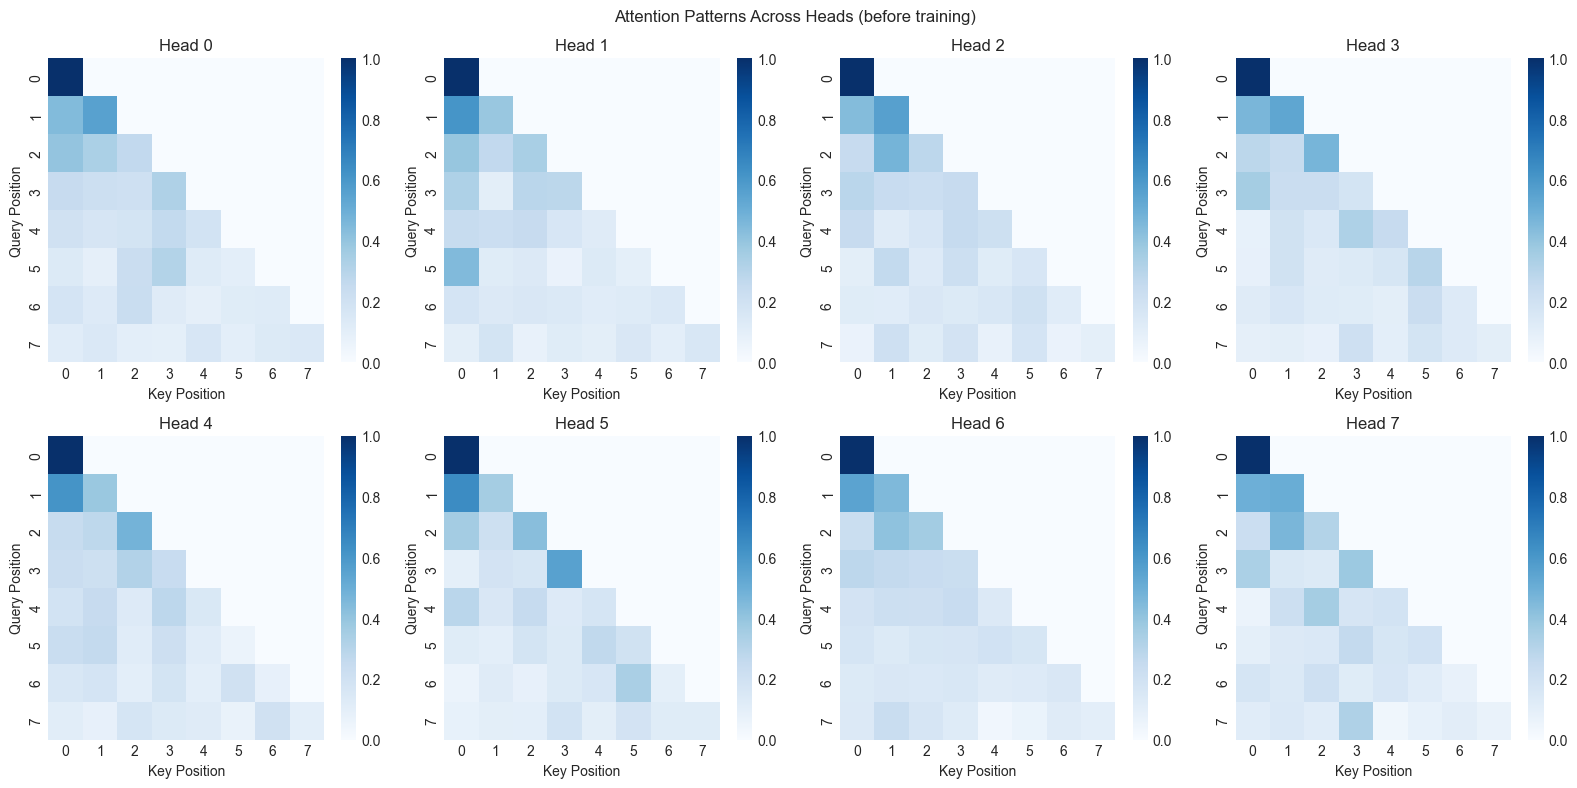

In [29]:
# Visualize attention patterns across heads
x = torch.randn(1, 8, d_model)  # Single example, 8 positions

with torch.no_grad():
    attn_weights = get_attention_weights(mha, x)  # (1, n_heads, 8, 8)

# Plot attention for each head
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for head in range(n_heads):
    ax = axes[head]
    sns.heatmap(
        attn_weights[0, head].numpy(),
        ax=ax,
        cmap='Blues',
        xticklabels=range(8),
        yticklabels=range(8),
    )
    ax.set_title(f'Head {head}')
    ax.set_xlabel('Key Position')
    ax.set_ylabel('Query Position')

plt.suptitle('Attention Patterns Across Heads (before training)')
plt.tight_layout()
plt.show()

## 6. Summary

### What You Learned

1. **Attention as soft lookup**: Query-Key matching determines Value aggregation
2. **Scaling**: Divide by √d_k to prevent gradient issues
3. **Causal masking**: Lower triangular mask for autoregressive models
4. **Multi-head attention**: Multiple parallel attention operations

### Key Formulas

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$$

### Preparation for Next Notebook

In Notebook 04, we'll combine attention with feed-forward networks to create a complete **Transformer Block**!